# AIMMD multi-system (multi-ligand) tutorial

This notebook shows how **one** AIMMD params file can drive **several chemical
systems at once** and train a **single shared committor model** that works for
either system. It is the multi-system counterpart of `1_toy_1d.ipynb` and, like
it, runs end-to-end on the **toy engine** (no GROMACS / no GPU) in a couple of
minutes.

We set up two toy "ligands" with **different atom counts** (1 and 2 atoms) to
demonstrate the part that makes a shared model non-trivial: a fixed
`descriptor_transform` / `atom_types` encoding maps both systems into the same
network input space.

What we cover:

1. Two toy systems and their initial transition paths.
2. A single multi-system `params.py` (`multi_system=True`).
3. A **shared-network** campaign (`multi_system_share_network=True`): one trainer,
   one network, balanced pooling of both systems.
4. Inspecting the per-system run layout and the one shared network.
5. The **separate-networks** mode for contrast.
6. Per-system **kinetics convergence** with the shared model.

## 0. Imports and working directory

Everything is created in a fresh temporary directory so the notebook is
self-contained and repeatable.

In [1]:
import os
import json
import tempfile
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt
import aimmd

work = tempfile.mkdtemp(prefix="aimmd_multi_")
os.chdir(work)
print("working directory:", work)

/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


working directory: /tmp/aimmd_multi_7q9wovf5


## 1. Two toy systems with different atom counts

Each "ligand" is a toy particle whose first coordinate sweeps `0 -> 10`, which
is a clean `A -> R -> B` transition for the state function below. System `s1`
has **1 atom**; system `s2` has **2 atoms** (the extra atom is inert and ignored
by the analysis functions). Writing different atom counts is the whole point:
the shared network must consume both.

In [2]:
def write_initial(fname, n_atoms, n_frames=50):
    u = mda.Universe.empty(n_atoms, trajectory=True)
    sweep = np.linspace(0.0, 10.0, n_frames)
    with mda.Writer(fname, n_atoms) as w:
        for x in sweep:
            u.atoms.positions = np.column_stack([
                np.full(n_atoms, x), np.full(n_atoms, 5.0),
                np.full(n_atoms, 5.0)]).astype(np.float32)
            w.write(u.atoms)

write_initial("s1.xtc", n_atoms=1)
write_initial("s2.xtc", n_atoms=2)
print("s1 atoms:", mda.Universe("s1.xtc").atoms.n_atoms)
print("s2 atoms:", mda.Universe("s2.xtc").atoms.n_atoms)

s1 atoms: 1
s2 atoms: 2


/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes in this universe to guess types from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes (elements, types, or names) in this universe to guess mass from
  warnings.warn(str(e))


## 2. One multi-system params file

The key fields:

- `multi_system = True` turns on multi-system mode.
- `multi_system_share_network = True` trains **one** network for both systems.
- `system_ids`, list-valued `topology`, and grouped `initial_paths` give one
  entry per system.
- `states_function(traj, system_id=...)` uses the `system_id` keyword to apply a
  **per-ligand** state boundary.
- `descriptor_transform(coords, system_id=...)` maps **any** atom count to a
  fixed width (here the first atom's x), so one `Linear(1, ...)` network consumes
  both systems. (For real graph networks you would instead pass a fixed
  `atom_types` table; the mechanism is identical.)
- `fit` simply forwards to the default trainer — its **only** change for
  multi-system is that it now accepts a *list* of PathEnsembles.

In [3]:
PARAMS = """
import numpy as np
import torch
from aimmd.network import fit as _fit
from aimmd.network.rescalable import Rescalable

engine = 'toy'
multi_system = True
multi_system_share_network = True
system_ids = ['s1', 's2']
topology = ['s1.xtc', 's2.xtc']
initial_paths = [['s1.xtc'], ['s2.xtc']]
free_overriding_states = 'all'


def toy_mdrun(ts):
    for _ in range(50):
        ts.positions = (ts.positions + .05 * np.random.normal()) % 10


def states_function(trajectory, system_id=None):
    cut_a = 2.0 if system_id == 's1' else 2.5      # per-ligand A boundary
    out = []
    for frame in trajectory:
        x = frame.positions[0, 0]
        out.append('A' if x < cut_a else ('B' if x > 8.0 else 'R'))
    return np.array(out, dtype='<U1')


def descriptor_transform(coordinates, system_id=None):
    arr = np.asarray(coordinates).reshape(np.asarray(coordinates).shape[0], -1, 3)
    return arr[:, :1, 0]                            # fixed width for any system


class Network(Rescalable):
    def __init__(self):
        super().__init__()
        self.input = torch.nn.Linear(1, 16)
        self.act = torch.nn.ReLU()
        self.output = torch.nn.Linear(16, 1)
        self.reset_parameters()
    def forward(self, x):
        return self.output(self.act(self.input(x[:, :1])))
    def reset_parameters(self):
        self.input.reset_parameters(); self.output.reset_parameters()

network = Network()


def fit(params, pathensemble, verbose=False, worker=None):
    return _fit(params, pathensemble, nbins=0, state_bins='all', augment='no',
                lr=1e-3, epochs=40, batch_size=128, stop=1e9,
                in_memory=True, graphs=False, verbose=verbose, worker=worker)
"""
with open("params.py", "w") as fh:
    fh.write(PARAMS)
print("wrote params.py")

wrote params.py


## 3. Load the params and inspect the multi-system plumbing

`Params` builds one MDAnalysis universe per system and keeps the initial paths
grouped per system.

In [4]:
params = aimmd.Params.load("params.py")
print("multi_system          :", params.multi_system)
print("share network         :", params.multi_system_share_network)
print("system_ids            :", params.system_ids)
print("topology (per system) :", params.topology)
print("universe atom counts  :",
      {sid: params.universe_of(sid).atoms.n_atoms for sid in params.system_ids})
print("initial-path groups   :", len(params.initial_paths))

Written full params with descriptions to 'params1.py'


multi_system          : True
share network         : True
system_ids            : ['s1', 's2']
topology (per system) : ['s1.xtc', 's2.xtc']
universe atom counts  : {'s1': 1, 's2': 2}
initial-path groups   : 2


## 4. Run a shared-network campaign

`Launcher.run(n, n1, n2)` worker counts apply **per system**. With
`n=1, n1=1, n2=1` each of `s1` and `s2` gets one shooting + one freeA + one freeB
worker, and a single shared trainer fits the network on **both** systems'
ensembles. (`nsteps` is tiny here — this is a functionality demo, not a
converged run.)

In [5]:
launcher = aimmd.Launcher("params.py", "run1")
launcher.run(n=1, n1=1, n2=1, nsteps=10, walltime=300)
print("campaign finished")

Assigned parameters file 'params1.py'


Assigned parameters file 'params1.py'


+++ created 'run1'
+++ created 'run1/s1'
+++ created 'run1/s1/initialARB'
+++ saved 'run1/s1/initialARB/s1.xtc.trr' (from: 's1.xtc')
+++ saved 'run1/s1/initialARB/s1.xtc.trr.states.npy'
+++ created run1/s1/freeA
+++ created run1/s1/freeB
+++ created run1/s1/chainR0
+++ created 'run1/s2'
+++ created 'run1/s2/initialARB'
+++ saved 'run1/s2/initialARB/s2.xtc.trr' (from: 's2.xtc')
+++ saved 'run1/s2/initialARB/s2.xtc.trr.states.npy'
+++ created run1/s2/freeA
+++ created run1/s2/freeB
+++ created run1/s2/chainR0


/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes in this universe to guess types from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes (elements, types, or names) in this universe to guess mass from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes in this universe to guess types from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes (elements, types, or names) in this universe to guess mass from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py

/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes in this universe to guess types from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes (elements, types, or names) in this universe to guess mass from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes in this universe to guess types from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes (elements, types, or names) in this universe to guess mass from
  warnings.warn(str(e))


...

[PID 3729030, TID 140492349171520: "run1/s2" freeA (worker0)] starting (Thu Jun 18 13:06:04 2026)
...   args: ('params1.py', 'run1/s2', np.int64(3), np.int64(4), 1, 'freeA/worker0.log', inf, inf, inf, 59.0, 'free', 'A', 0, np.int64(1), np.True_)
[PID 3729030, TID 140492349171520: "run1/s2" freeA (worker0)] exited correctly


[PID 3729022, TID 140677381478208: "run1/s1" chainR0] starting (Thu Jun 18 13:05:59 2026)
...   args: ('params1.py', 'run1/s1', np.int64(2), np.int64(4), 1, 'chainR0/worker.log', inf, inf, inf, 59.0, 'shoot', 'R', 0, False)
[PID 3729022, TID 140677381478208: "run1/s1" chainR0] exited correctly
[PID 3729035, TID 139753042200384: "run1/s2" chainR0] starting (Thu Jun 18 13:05:59 2026)
...   args: ('params1.py', 'run1/s2', np.int64(5), np.int64(4), 1, 'chainR0/worker.log', inf, inf, inf, 59.0, 'shoot', 'R', 0, False)
[PID 3729035, TID 139753042200384: "run1/s2" chainR0] exited correctly


[PID 3729017, TID 140295971784512: "run1/s1" freeB (worker0)] starting (Thu Jun 18 13:05:59 2026)
...   args: ('params1.py', 'run1/s1', np.int64(1), np.int64(4), 1, 'freeB/worker0.log', inf, inf, inf, 59.0, 'free', 'B', 0, np.int64(1), np.True_)
[PID 3729017, TID 140295971784512: "run1/s1" freeB (worker0)] exited correctly


[PID 3728994, TID 139924508813120: "run1/s1" freeA (worker0)] starting (Thu Jun 18 13:05:59 2026)
...   args: ('params1.py', 'run1/s1', np.int64(0), np.int64(4), 1, 'freeA/worker0.log', inf, inf, inf, 59.0, 'free', 'A', 0, np.int64(1), np.True_)
[PID 3728994, TID 139924508813120: "run1/s1" freeA (worker0)] exited correctly


campaign finished


## 5. The per-system layout and the one shared network

A multi-system run nests one level: each system has its own subfolder with its
own chains, free simulations and adaptive bins/densities. The **single** shared
network lives at the run root and is read by every system's workers.

In [6]:
def tree(root, depth=0):
    for name in sorted(os.listdir(root)):
        path = os.path.join(root, name)
        print("  " * depth + ("[d] " if os.path.isdir(path) else "    ") + name)
        if os.path.isdir(path) and depth < 1:
            tree(path, depth + 1)

tree("run1")
print()
print("shared network at root :", os.path.isfile("run1/networkARB.h5"))
print("per-system networks    :",
      {sid: os.path.isfile(f"run1/{sid}/networkARB.h5") for sid in params.system_ids})
print("per-system bins        :",
      {sid: os.path.isfile(f"run1/{sid}/binsARB.npy") for sid in params.system_ids})

    networkARB.h5
    networkARB.step000000.h5
    networkARB.step000010.h5
[d] s1
      binsARB.npy
  [d] chainR0
      densitiesARB.npy
  [d] freeA
  [d] freeB
  [d] initialARB
[d] s2
      binsARB.npy
  [d] chainR0
      densitiesARB.npy
  [d] freeA
  [d] freeB
  [d] initialARB
    trainARB.log

shared network at root : True
per-system networks    : {'s1': False, 's2': False}
per-system bins        : {'s1': True, 's2': True}


## 6. The shared model predicts the committor for both systems

We load the one shared network and evaluate the committor along the reaction
coordinate for **each** system. Because the systems have different atom counts,
this only works thanks to the shared `descriptor_transform` encoding.

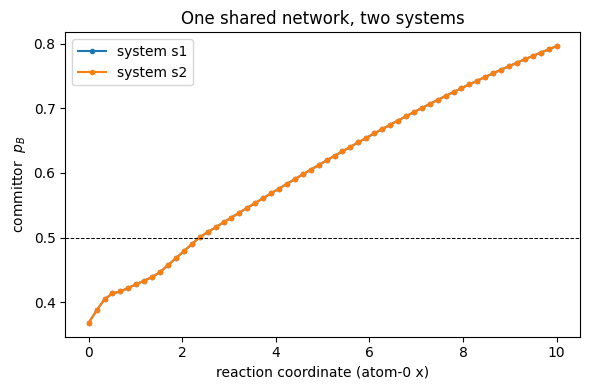

In [7]:
import torch
from scipy.special import expit

params.update_network("run1")          # loads run1/networkARB.h5 (shared)
xs = np.linspace(0, 10, 60)

plt.figure(figsize=(6, 4))
for sid, n_atoms in (("s1", 1), ("s2", 2)):
    coords = np.zeros((len(xs), n_atoms * 3), dtype=np.float32)
    coords[:, 0] = xs                  # atom-0 x = reaction coordinate
    logit = params.values_function(coords, system_id=sid)
    plt.plot(xs, expit(logit), "o-", ms=3, label=f"system {sid}")
plt.axhline(0.5, color="k", lw=0.7, ls="--")
plt.xlabel("reaction coordinate (atom-0 x)")
plt.ylabel("committor  $p_B$")
plt.title("One shared network, two systems")
plt.legend(); plt.tight_layout(); plt.show()

## 7. Separate networks (for contrast)

With `multi_system_share_network = False`, each ligand trains its **own** network
in its own subfolder (one trainer per system; `trainers_share_gpu` decides
whether they share a GPU). Everything else — the single params file, the
subfolder layout, the per-system worker counts — is identical.

In [8]:
sep = PARAMS.replace("multi_system_share_network = True",
                     "multi_system_share_network = False")
os.makedirs("sep", exist_ok=True)
write_initial("sep/s1.xtc", 1); write_initial("sep/s2.xtc", 2)
with open("sep/params.py", "w") as fh:
    fh.write(sep)
here = os.getcwd(); os.chdir("sep")
try:
    aimmd.Launcher("params.py", "run1").run(n=1, n1=1, n2=1, nsteps=10, walltime=300)
    print("per-system networks    :",
          {sid: os.path.isfile(f"run1/{sid}/networkARB.h5") for sid in ("s1", "s2")})
    print("shared network at root :", os.path.isfile("run1/networkARB.h5"))
finally:
    os.chdir(here)

Written full params with descriptions to 'params1.py'


Assigned parameters file 'params1.py'


+++ created 'run1'
+++ created 'run1/s1'
+++ created 'run1/s1/initialARB'
+++ saved 'run1/s1/initialARB/s1.xtc.trr' (from: 's1.xtc')
+++ saved 'run1/s1/initialARB/s1.xtc.trr.states.npy'
+++ created run1/s1/freeA
+++ created run1/s1/freeB
+++ created run1/s1/chainR0
+++ created 'run1/s2'
+++ created 'run1/s2/initialARB'
+++ saved 'run1/s2/initialARB/s2.xtc.trr' (from: 's2.xtc')
+++ saved 'run1/s2/initialARB/s2.xtc.trr.states.npy'
+++ created run1/s2/freeA
+++ created run1/s2/freeB
+++ created run1/s2/chainR0


/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes in this universe to guess types from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes (elements, types, or names) in this universe to guess mass from
  warnings.warn(str(e))


/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes in this universe to guess types from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes (elements, types, or names) in this universe to guess mass from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes in this universe to guess types from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py:1916: UserWarning: there is no reference attributes (elements, types, or names) in this universe to guess mass from
  warnings.warn(str(e))
/home/lichtinger/anaconda3/envs/new_aimmd/lib/python3.13/site-packages/MDAnalysis/core/universe.py

...

[PID 3731783, TID 140548236474176: "run1/s1" freeB (worker0)] starting (Thu Jun 18 13:07:01 2026)
...   args: ('params1.py', 'run1/s1', np.int64(1), np.int64(3), 1, 'freeB/worker0.log', inf, inf, inf, 59.0, 'free', 'B', 0, np.int64(1), np.True_)
[PID 3731783, TID 140548236474176: "run1/s1" freeB (worker0)] exited correctly


[PID 3731787, TID 139845553997632: "run1/s2" freeB (worker0)] starting (Thu Jun 18 13:07:01 2026)
...   args: ('params1.py', 'run1/s2', np.int64(5), np.int64(3), 1, 'freeB/worker0.log', inf, inf, inf, 59.0, 'free', 'B', 0, np.int64(1), np.True_)
[PID 3731787, TID 139845553997632: "run1/s2" freeB (worker0)] exited correctly


[PID 3731784, TID 139688858773312: "run1/s1" chainR0] starting (Thu Jun 18 13:07:01 2026)
...   args: ('params1.py', 'run1/s1', np.int64(2), np.int64(3), 1, 'chainR0/worker.log', inf, inf, inf, 59.0, 'shoot', 'R', 0, False)
[PID 3731784, TID 139688858773312: "run1/s1" chainR0] exited correctly


[PID 3731788, TID 140356780934976: "run1/s2" chainR0] starting (Thu Jun 18 13:07:01 2026)
...   args: ('params1.py', 'run1/s2', np.int64(6), np.int64(3), 1, 'chainR0/worker.log', inf, inf, inf, 59.0, 'shoot', 'R', 0, False)
[PID 3731788, TID 140356780934976: "run1/s2" chainR0] exited correctly
[PID 3731782, TID 140097597011776: "run1/s1" freeA (worker0)] starting (Thu Jun 18 13:07:01 2026)
...   args: ('params1.py', 'run1/s1', np.int64(0), np.int64(3), 1, 'freeA/worker0.log', inf, inf, inf, 59.0, 'free', 'A', 0, np.int64(1), np.True_)
[PID 3731782, TID 140097597011776: "run1/s1" freeA (worker0)] exited correctly


per-system networks    : {'s1': True, 's2': True}
shared network at root : False


## 8. Per-system kinetics convergence (shared model)

`kinetics_convergence` works with the shared model: at each data fraction it
retrains the shared network on both systems' sub-sampled ensembles and reports
rates **per system**. The result array carries a `system` field.

In [9]:
worker = aimmd.Worker(params, "run1", walltime=300)
results = worker.kinetics_convergence(fractions=[0.5, 1.0])
print("fields:", results.dtype.names)
for row in results:
    print(f"  system {row['system']:>3}  fraction {row['fraction']:.2f}  "
          f"k12={row['k12']:.2e}  k21={row['k21']:.2e}")

Press Control+C to interrupt.



Worker's resources info


-----------------------


LocalID 0


CPU ids: 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27


...

    [system 's1'] k12=1.783e-03 k21=1.568e-03 [1/dt], 4903 frames


    [system 's2'] k12=1.746e-03 k21=3.432e-03 [1/dt], 4750 frames



Restoring original network state (Thu Jun 18 13:08:09 2026)


Saved per-system kinetics convergence to 'kinetics_convergence.npy'


fields: ('fraction', 'system', 'n_frames', 'k12', 'k21', 'k12_rw', 'k21_rw')
  system  s1  fraction 0.50  k12=7.64e-04  k21=5.18e-04
  system  s2  fraction 0.50  k12=1.56e-03  k21=6.44e-04
  system  s1  fraction 1.00  k12=1.78e-03  k21=1.57e-03
  system  s2  fraction 1.00  k12=1.75e-03  k21=3.43e-03


## Summary

With a single params file and the `multi_system` switches we trained **one**
committor network that serves two systems with different atom counts, balanced
so neither dominates — and contrasted it with the separate-network mode. The
same configuration scales to real systems (e.g. a graph/PaiNN network with a
fixed `atom_types` table over many ligands) and to live HPC campaigns via
`Launcher.create_job`.